# Lab 4 - LDPC Factor Graph Construction

This is the first of the two colab notebooks that form the project.

Here you will construct a **factor graph** for decoding a (regular)
**low-density parity-check (LDPC)** code. Although communication systems often
refer to messages and codewords, in this lab we model only the transmitted bits
$x$ and the channel outputs $y$. All other steps are either preprocessing
(encoding) or postprocessing (reading off the decoded bits).

As the block length $N$ increases, well-designed LDPC codes achieve better decoding performance, while the treewidth of the factor graph grows, making exact inference intractable and motivating approximate methods such as belief propagation.


## Learning goals

- Represent an LDPC code as a **factor graph** with:
  - binary **variable nodes** (bits),
  - **parity-check factors** (XOR constraints),
  - **channel factors** connecting each transmitted bit to its channel output.
- Validate the graph:
  - **structurally**: degrees, factor arities, correct wiring,
  - **semantically**: parity-check factors behave correctly on a known satisfying assignment.

You will be given:
- a generator for a *regular* parity-check matrix $H$ (with configurable density),
- a Binary Symmetric Channel (BSC) noise generator.

You will implement:
1. a parity-check factor constructor,
2. a channel factor constructor,
3. the factor-graph construction from $H$,
4. graph validation checks and visualization,
5. treewidth scaling analysis.

In [110]:
# Colab setup
#!pip -q install pgmpy networkx

In [111]:
import numpy as np
import itertools
import networkx as nx

from pgmpy.models import FactorGraph
from pgmpy.factors.discrete import DiscreteFactor

# Factor graphs for Low-Density Parity-Check (LDPC) decoding

## Variables and factorization

The task is to transmit $N$ bits over a noisy channel. LDPC codes introduce $M$
parity-check constraints to enable error correction.

The factor graph contains two types of binary variables:
- **transmitted bits**: $x_0,\dots,x_{N-1}$
- **channel outputs**: $y_0,\dots,y_{N-1}$

The joint distribution defined by the factor graph factorizes as
$$
p(x,y)
\;\propto\;
\prod_{m=1}^M \psi_m\bigl(x_{N(m)}\bigr)
\;\;
\prod_{n=0}^{N-1} \phi_n(x_n, y_n),
$$

where $N(m)$ denotes the set of transmitted-bit indices that appear in factor
$\psi_m$, and:
- $\psi_m$ are **parity-check factors** enforcing local constraints on transmitted bits,
- $\phi_n$ are **channel factors** modeling the noise affecting each bit.

## Parity-check factors $\psi_m(x_{N(m)})$

Each parity-check factor enforces an even-parity constraint on a small subset of
transmitted bits.

Formally, the factor is defined as
$$
\psi_m\bigl(x_{N(m)}\bigr)
\;=\;
\begin{cases}
1 & \text{if } \sum_{n \in N(m)} x_n \equiv 0 \pmod 2, \\
0 & \text{otherwise}.
\end{cases}
$$

Thus, each parity-check factor is a **local constraint** that involves only the
$k$ transmitted-bit variables connected to it.

## Channel factors $\phi_n(x_n,y_n)$

Each channel factor connects a transmitted bit $x_n$ to its corresponding channel
output $y_n$.

We model the channel as a **binary symmetric channel (BSC)** with flip probability
$f$, defining
$$
\phi_n(x_n,y_n)
=
p(y_n \mid x_n)
=
\begin{cases}
1-f & \text{if } y_n = x_n, \\
f   & \text{if } y_n \neq x_n.
\end{cases}
$$

Channel factors are independent across bit positions.

## Decoding as inference

In a communication scenario, the channel outputs
$y_0,\dots,y_{N-1}$ are observed.

Decoding consists of inferring the transmitted bits
$x_0,\dots,x_{N-1}$ given these observations, that is, computing the posterior
distribution $p(x \mid y)$.

In the next session, you will approximate this posterior using belief propagation on the same factor graph, after introducing evidence on the $y$ variables.

## Regular LDPC parity-check matrix generator

A **regular LDPC code** is specified by a sparse parity-check matrix $H \in \{0,1\}^{M \times N},$which defines the structure of the parity-check factors in the factor graph.

- Each row corresponds to one parity-check factor.
- Each column corresponds to one transmitted-bit variable.
- Each row has exactly $k$ ones (each check involves $k$ bits).
- Each column has exactly $j$ ones (each bit participates in $j$ checks).

For a given row $m$, the set
$$
N(m) = \{\, n : H_{m,n} = 1 \,\}
$$
is exactly the set of transmitted bits connected to parity-check factor $\psi_m$.

The following code generates a random **regular LDPC** parity-check matrix:
- each **column** has weight $j$,
- each **row** has weight $k$.

If generation fails (rare for small sizes), re-run the cell or adjust the parameters.

In [112]:
def generate_regular_ldpc_H(N: int, j: int, k: int, seed: int = 0, max_tries: int = 2000) -> np.ndarray:
    """Generate a random (j,k)-regular binary parity-check matrix H of shape (M,N),
    where M = N*j/k must be an integer.

    Notes:
    - This construction is intentionally simple (sufficient for the lab).
    - It may create short cycles; that's fine (Lab 2 is loopy).
    """
    rng = np.random.default_rng(seed)
    if (N * j) % k != 0:
        raise ValueError(f"Need M = N*j/k integer, but N*j={N*j} not divisible by k={k}.")
    M = (N * j) // k

    for _ in range(max_tries):
        # Create j "stubs" per column
        col_stubs = np.repeat(np.arange(N), j)
        rng.shuffle(col_stubs)

        # Assign stubs into M groups of size k (rows)
        H = np.zeros((M, N), dtype=np.uint8)
        ok = True
        for m in range(M):
            cols = col_stubs[m * k : (m + 1) * k]
            # avoid duplicate variable in a single check (keeps row weight exactly k)
            if len(set(cols.tolist())) != k:
                ok = False
                break
            H[m, cols] = 1
        if not ok:
            continue

        # Verify regularity
        if np.all(H.sum(axis=0) == j) and np.all(H.sum(axis=1) == k):
            return H

    raise RuntimeError("Failed to construct a regular LDPC matrix. Try a different seed or parameters.")

## Part 1: Choose code parameters and generate $H$

Pick modest sizes so you can visualize and test easily.
Suggested starting point:
- $N=24$, $j=3$, $k=6$  (then $M=\frac{N j}{k} = 12$)

In [113]:
# TODO: Choose parameters
N = 24
j = 3
k = 6
seed_H = 0

H = generate_regular_ldpc_H(N=N, j=j, k=k, seed=seed_H)
M = H.shape[0]
print(H)

print("H shape:", H.shape)
print("column weights (should all be j):", np.unique(H.sum(axis=0)))
print("row weights (should all be k):", np.unique(H.sum(axis=1)))

[[1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1]
 [0 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0]
 [0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0]
 [0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0]
 [0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0]
 [1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 0]]
H shape: (12, 24)
column weights (should all be j): [3]
row weights (should all be k): [6]


## Part 2: Build factors

### 2.1 Parity-check factors $\psi_m(x_{N(m)})$

Implement `make_parity_check_factor` which receives a matrix $H$, a set of variables, and returns a factor defined over the transmitted-bit variables connected to that row.

It should be:
- value = 1 if the parity constraint is satisfied (even parity)
- value = 0 otherwise

Tips:
- With `DiscreteFactor`, you provide a `values` array of length $2^d$ (reshaped to `[2]*d`),
  where `d` is the number of variables in that factor.
- You can generate all assignments with `itertools.product([0,1], repeat=d)`.

<center>
<table>
  <thead>
    <tr>
      <th>$x_1$</th>
      <th>$x_2$</th>
      <th>$x_3$</th>
      <th>$\psi_{{123}}$</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>0</td><td>0</td><td>0</td><td>1</td></tr>
    <tr><td>0</td><td>0</td><td>1</td><td>0</td></tr>
    <tr><td>0</td><td>1</td><td>0</td><td>0</td></tr>
    <tr><td>0</td><td>1</td><td>1</td><td>1</td></tr>
    <tr><td>1</td><td>0</td><td>0</td><td>0</td></tr>
    <tr><td>1</td><td>0</td><td>1</td><td>1</td></tr>
    <tr><td>1</td><td>1</td><td>0</td><td>1</td></tr>
    <tr><td>1</td><td>1</td><td>1</td><td>0</td></tr>
  </tbody>
</table>
<br>Example of a 3-wise parity-check factor
</center>

In [114]:
def make_parity_check_factor(var_names):
    """Return a DiscreteFactor enforcing even parity over var_names.
    """
    factor = DiscreteFactor(var_names, [2] * len(var_names), np.zeros(2 ** len(var_names)))
    for combination in itertools.product([0, 1], repeat=len(var_names)):
        if sum(combination) % 2 == 0:
            factor.values[combination] = 1.0
    return factor


In [115]:
factor = make_parity_check_factor(["X1", "X2", "X3"])
print("Variables:", factor.variables)
print("Cardinalities:", factor.cardinality)
print("Factor:", factor)

Variables: ['X1', 'X2', 'X3']
Cardinalities: [2 2 2]
Factor: +-------+-------+-------+-----------------+
| X1    | X2    | X3    |   phi(X1,X2,X3) |
+=======+=======+=======+=================+
| X1(0) | X2(0) | X3(0) |          1.0000 |
+-------+-------+-------+-----------------+
| X1(0) | X2(0) | X3(1) |          0.0000 |
+-------+-------+-------+-----------------+
| X1(0) | X2(1) | X3(0) |          0.0000 |
+-------+-------+-------+-----------------+
| X1(0) | X2(1) | X3(1) |          1.0000 |
+-------+-------+-------+-----------------+
| X1(1) | X2(0) | X3(0) |          0.0000 |
+-------+-------+-------+-----------------+
| X1(1) | X2(0) | X3(1) |          1.0000 |
+-------+-------+-------+-----------------+
| X1(1) | X2(1) | X3(0) |          1.0000 |
+-------+-------+-------+-----------------+
| X1(1) | X2(1) | X3(1) |          0.0000 |
+-------+-------+-------+-----------------+


## Channel factors $\phi_n(x_n,y_n)$

Implement `make_bsc_channel_factor(x_var, y_var, f)`,
a **pairwise factor** over `(x_var, y_var)` defined by a **binary symmetric channel (BSC)** with flip probability $f$.

In [116]:
def make_bsc_channel_factor(x_var, y_var, f):
    """Pairwise channel factor for a BSC.
    Returns a DiscreteFactor over [x_var, y_var] with cardinalities [2,2].
    """
    factor = DiscreteFactor([x_var, y_var], [2, 2], np.zeros(4))
    for combination in itertools.product([0, 1], repeat=2):
        x, y = combination
        if x == y:
            factor.values[combination] = 1 - f
        else:
            factor.values[combination] = f
    return factor

In [117]:
channel_factor = make_bsc_channel_factor("X", "Y", f=0.1)
print("Variables:", channel_factor.variables)
print("Cardinalities:", channel_factor.cardinality)
print("Factor:", channel_factor)

Variables: ['X', 'Y']
Cardinalities: [2 2]
Factor: +------+------+------------+
| X    | Y    |   phi(X,Y) |
+======+======+============+
| X(0) | Y(0) |     0.9000 |
+------+------+------------+
| X(0) | Y(1) |     0.1000 |
+------+------+------------+
| X(1) | Y(0) |     0.1000 |
+------+------+------------+
| X(1) | Y(1) |     0.9000 |
+------+------+------------+


## Part 3: Create the factor graph from $H$

Construct a `pgmpy` `FactorGraph`:

1. add variable nodes: `x0...x{N-1}`
2. add parity-check factors (one per row of H) and connect them
3. (optional today, required later) add likelihood factors and connect them

Implement:
- `build_ldpc_factor_graph(H, y=None, f=None)`

In [118]:
def build_ldpc_factor_graph(H: np.ndarray, f: float) -> FactorGraph:
    """Build an LDPC factor graph with explicit channel-output variables.

    Variables:
      - transmitted bits: x0..x{N-1}
      - channel outputs:  y0..y{N-1}

    Factors:
      - parity-check factors on x's (from H)
      - channel factors φ_n(x_n, y_n) = p(y_n | x_n) for BSC flip prob f

    Evidence (a particular received word Y) will be introduced later by clamping y's.
    """
    M, N = H.shape
    x_vars = [f"x{n}" for n in range(N)]
    y_vars = [f"y{n}" for n in range(N)]

    G = FactorGraph()

    # 1) Add variable nodes
    for var in x_vars + y_vars:
        G.add_node(var)

    # 2) Add parity-check factors (one per row of H) and connect them
    for m in range(M):
        var_names = [x_vars[n] for n in range(N) if H[m, n] == 1]
        factor = make_parity_check_factor(var_names)
        G.add_factors(factor)
        for var in var_names:
            G.add_edge(var, factor)

    # 3) Add channel factors φ_n(x_n, y_n) and connect them
    for n in range(N):
        factor = make_bsc_channel_factor(x_vars[n], y_vars[n], f)
        G.add_factors(factor)
        G.add_edge(x_vars[n], factor)
        G.add_edge(y_vars[n], factor)

    return G

## Part 4: Validating the factor graph

We must verify that the factor graph correctly represents the intended LDPC model.

Your task in this part is to **think about validations that make
sense**, and to implement some of them.

Examples of questions you may consider include:
### Structural checks:

- Does the number and type of factors match the specification of the LDPC code?
- Are parity-check factors connected to the correct subsets of transmitted bits?
- Do variable nodes have the expected degrees (for a regular code)?
- Do parity-check factors behave correctly on a known satisfying assignment?
### Semantic checks:
For small $N$, you can test the parity-check factors exhaustively.

For each assignment $x \in \{0,1\}^N$ (there are $2^N$ of them), compute the so-called *syndrome*
$$
s = Hx \pmod 2.
$$
The parity-check constraints are satisfied if and only if $s=0$, so the product of
all parity-check factors should evaluate to
$$
\prod_{m=1}^M \psi_m(x_{N(m)}) =
\begin{cases}
1 & \text{if } Hx \equiv 0 \pmod 2,\\
0 & \text{otherwise.}
\end{cases}
$$

For this semantic test you can ignore the $y$ variables and the channel factors.


In [119]:
def validate_ldpc_graph(
    G,
    H: np.ndarray,
    f: float,
    num_random_assignments: int = 1000,
    exhaustive_max_n: int = 14,
    seed: int = 0,
):
    """Validation suite for an LDPC factor graph.

    Checks performed:
      1) basic pgmpy model validity
      2) node/factor counts and variable naming
      3) parity/channel factor arities and counts
      4) wiring consistency with H
      5) local factor semantics (parity + BSC channel)
      6) global parity consistency on exhaustive/random x assignments
    """
    if not (0.0 <= f <= 1.0):
        # This is a sanity check for the flip probability parameter, which should be in the range [0, 1].
        raise ValueError("Flip probability f must be in [0, 1].")

    M, N = H.shape
    rng = np.random.default_rng(seed)

    # 1) Basic pgmpy model validity
    assert G.check_model(), "Basic LDPC graph validation failed (G.check_model())."

    factors = list(G.get_factors())
    factor_set = set(factors)
    all_nodes = list(G.nodes())
    variable_nodes = [node for node in all_nodes if node not in factor_set]

    expected_x = {f"x{n}" for n in range(N)}
    expected_y = {f"y{n}" for n in range(N)}
    variable_names = {node for node in variable_nodes if isinstance(node, str)}

    # 2) Variable count check and variable naming
    assert variable_names == (expected_x | expected_y), (
        "Variable nodes mismatch. "
        f"Expected {2 * N} nodes x/y, got {len(variable_names)} named variables."
    )
    # Variable node count should be X + Y = 2N
    assert len(variable_nodes) == 2 * N, f"Expected {2*N} variable nodes, got {len(variable_nodes)}"

    parity_factors = []
    channel_factors = []

    for fac in factors:
        fac_vars = list(fac.variables)
        if len(fac_vars) == 2 and any(v.startswith("y") for v in fac_vars):
            # Channel factor should connect one x and one y variable, and has the format φ_n(x_n, y_n) = p(y_n | x_n) for BSC flip prob f
            channel_factors.append(fac)
        elif all(v.startswith("x") for v in fac_vars):
            # Parity factor has the form φ(x_{i1}, x_{i2}, ..., x_{id}) = 1 iff sum of x_{ij} is even, else 0.
            parity_factors.append(fac)

    # 3) Factor count checks
    assert len(parity_factors) == M, f"Expected {M} parity factors, got {len(parity_factors)}"
    assert len(channel_factors) == N, f"Expected {N} channel factors, got {len(channel_factors)}"
    assert len(factors) == (M + N), f"Expected {M+N} total factors, got {len(factors)}"

    # Degree checks: x_n should have deg = column_weight(H[:, n]) + 1 ; y_n should have deg = 1
    for n in range(N):
        x_n = f"x{n}"
        y_n = f"y{n}"

        deg_x = len(list(G.neighbors(x_n)))
        deg_y = len(list(G.neighbors(y_n)))

        # Expected degree for x_n is number of parity checks it participates in (sum of column in H) + 1 for channel factor
        expected_deg_x = int(H[:, n].sum()) + 1
        assert deg_x == expected_deg_x, (
            f"Degree mismatch for {x_n}: expected {expected_deg_x}, got {deg_x}"
        )
        # Expected degree for y_n is 1 (only connected to its channel factor)
        assert deg_y == 1, f"Degree mismatch for {y_n}: expected 1, got {deg_y}"

    # Parity wiring consistency with H (multiset compare of scopes)
    expected_parity_scopes = []
    for m in range(M):
        # H[m] is the m-th row; np.where(H[m] == 1)[0] gives indices of x variables in this parity check
        # H[m] = [0, 1, 0, 1, 1] -> scope = {x1, x3, x4}
        scope = frozenset(f"x{n}" for n in np.where(H[m] == 1)[0])
        expected_parity_scopes.append(scope)

    actual_parity_scopes = []
    for fac in parity_factors:
        scope = list(fac.variables)
        # Format is φ(x_{i1}, x_{i2}, ..., x_{id}) = 1/0
        assert all(v.startswith("x") for v in scope), "Parity factor includes non-x variable."
        actual_parity_scopes.append(frozenset(scope))

    from collections import Counter

    # We use Counter to compare the multisets of parity scopes, since the order of factors is not guaranteed.
    assert Counter(actual_parity_scopes) == Counter(expected_parity_scopes), (
        "Parity-factor scopes do not match H row neighborhoods."
    )

    # Channel wiring and semantics
    seen_channel_pairs = set()

    for fac in channel_factors:
        scope = list(fac.variables)
        # Each channel factor should have exactly 2 variables (x_n and y_n).
        assert len(scope) == 2, "Channel factor must be pairwise."
        x_vars = [v for v in scope if v.startswith("x")]
        y_vars = [v for v in scope if v.startswith("y")]
        # Each channel factor should connect exactly one x and one y variable,
        assert len(x_vars) == 1 and len(y_vars) == 1, "Channel factor must connect one x and one y variable."

        x_var, y_var = x_vars[0], y_vars[0]
        ix = int(x_var[1:])
        iy = int(y_var[1:])
        # The indices should match (i.e., x_n connected to y_n).
        assert ix == iy, f"Channel factor mismatch: {x_var} connected to {y_var}."

        seen_channel_pairs.add((ix, iy))

    # Check that we have exactly the expected set of channel pairs (x_n, y_n) for n in [0, N-1].
    assert seen_channel_pairs == {(n, n) for n in range(N)}, "Missing or duplicate channel factors."

    # For each parity factor φ_m, we explicitly enumerate all 2^d assignments
    # (where d is the degree of that parity check) and verify that:
    #
    #   φ_m(x_{i1}, ..., x_{id}) =
    #       1  if sum(x_{ij}) mod 2 == 0
    #       0  otherwise
    #
    # This guarantees that each parity factor is implemented exactly as a hard XOR constraint.
    for fac in parity_factors:
        scope = list(fac.variables)
        d = len(scope)
        for bits in itertools.product([0, 1], repeat=d):
            # Retrieve the actual factor value for this assignment
            got = float(fac.values[bits])

            # Expected value under even-parity (XOR) semantics
            expected = 1.0 if (sum(bits) % 2 == 0) else 0.0

            assert np.isclose(got, expected), (
                f"Parity factor semantic mismatch on scope {scope} and assignment {bits}."
            )

    # We now validate that the PRODUCT of all parity factors equals 1 if and only if Hx ≡ 0 (mod 2), i.e., x is a valid codeword.
    # If N is small, we exhaustively enumerate all 2^N assignments, otherwise, we randomly sample assignments for scalability.
    x_names = [f"x{n}" for n in range(N)]

    def parity_product_for_assignment(x_bits):
        # Build assignment dictionary for x variables
        assign = {name: int(bit) for name, bit in zip(x_names, x_bits)}

        # Multiply all parity factor values for this assignment
        prod = 1.0
        for fac in parity_factors:
            scope = list(fac.variables)
            idx = tuple(assign[v] for v in scope)
            prod *= float(fac.values[idx])

            # Early stopping: if any parity factor is zero,
            # the product is zero and parity is violated.
            if prod == 0.0:
                break

        return prod

    # Choose exhaustive or random testing depending on N
    if N <= exhaustive_max_n:
        # Exhaustively check all 2^N bit assignments
        assignments = itertools.product([0, 1], repeat=N)
    else:
        # Randomly sample assignments when exhaustive testing is infeasible
        assignments = (rng.integers(0, 2, size=N).tolist()
                    for _ in range(num_random_assignments))

    checked = 0
    for x_bits in assignments:
        x_arr = np.asarray(x_bits, dtype=int)

        # Compute algebraic syndrome Hx mod 2
        syndrome_zero = np.all((H @ x_arr) % 2 == 0)

        # Compute factor-graph parity evaluation (product > 0 means all constraints satisfied)
        parity_ok = parity_product_for_assignment(x_bits) > 0.5

        # The factor graph must accept exactly the same assignments
        # as those satisfying Hx ≡ 0 (mod 2).
        assert parity_ok == syndrome_zero, "Global parity consistency failed."

        checked += 1

    print(
        f"Validation passed: N={N}, M={M}, factors={len(factors)}, "
        f"parity_factors={len(parity_factors)}, channel_factors={len(channel_factors)}, "
        f"assignments_checked={checked}"
    )
    return True

In [120]:
# Smoke test for graph construction + validation
N = 24
j = 3
k = 6
seed_H = 0
f = 0.08

H = generate_regular_ldpc_H(N=N, j=j, k=k, seed=seed_H)
G = build_ldpc_factor_graph(H, f=f)
validate_ldpc_graph(G, H=H, f=f, num_random_assignments=2000, seed=0)

Validation passed: N=24, M=12, factors=36, parity_factors=12, channel_factors=24, assignments_checked=2000


True

## Part 5: Visualization

Implement code that visualizes a factor graph.

You can use `networkx` and `matplotlib.pyplot`, and all the functions from that library such as `nx.draw_networkx_nodes`


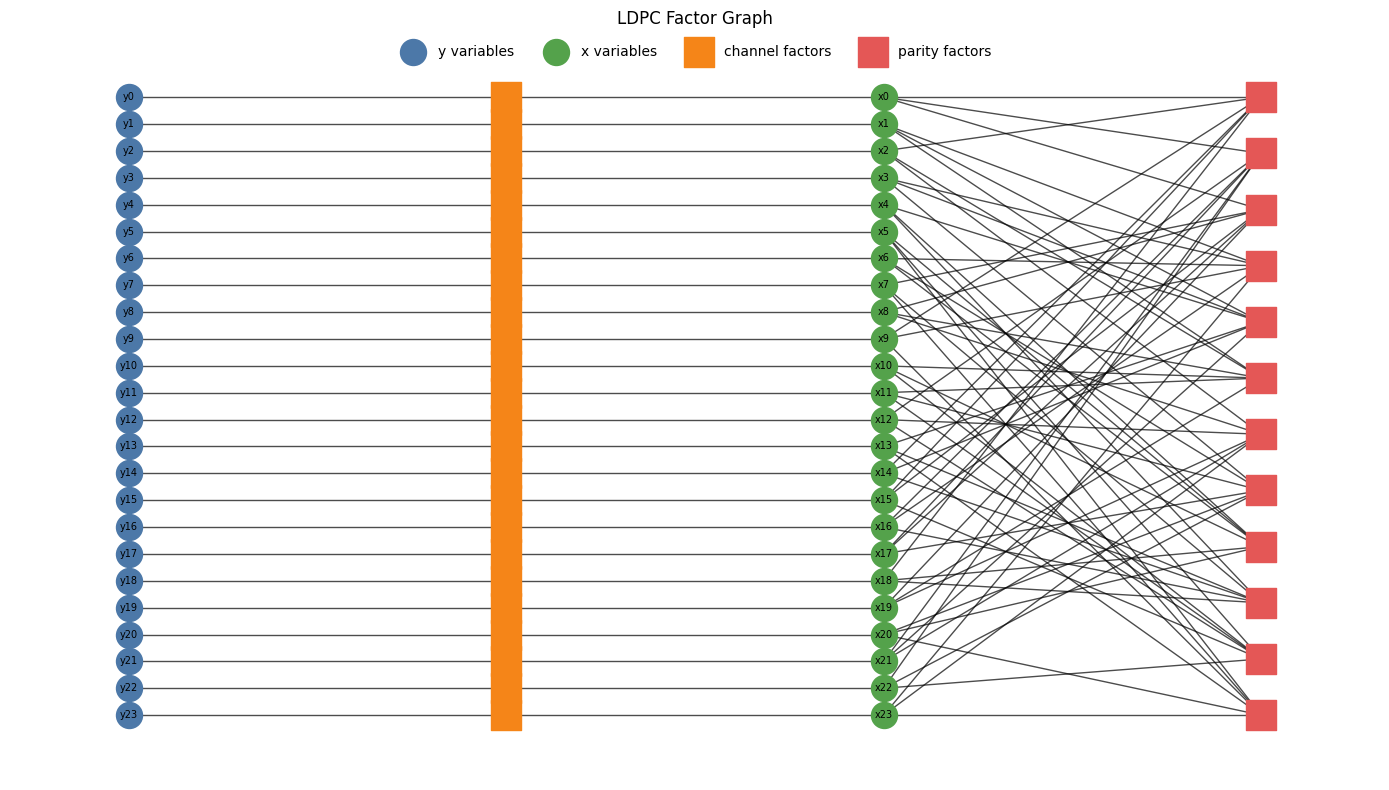

In [121]:
import matplotlib.pyplot as plt
import networkx as nx
from pgmpy.models import FactorGraph

def visualize_factor_graph(G: FactorGraph, max_nodes: int = 200):
    """Visualize an LDPC factor graph with a fixed column layout.

    Columns (left to right):
      y variables → channel factors → x variables → parity-check factors
    """
    Hnx = nx.Graph()

    factors = list(G.get_factors())
    factor_set = set(factors)
    variable_nodes = [node for node in G.nodes() if node not in factor_set]

    x_vars = sorted([v for v in variable_nodes if isinstance(v, str) and v.startswith("x")], key=lambda s: int(s[1:]))
    y_vars = sorted([v for v in variable_nodes if isinstance(v, str) and v.startswith("y")], key=lambda s: int(s[1:]))

    channel_factors = [fac for fac in factors if any(v.startswith("y") for v in fac.variables)]
    parity_factors = [fac for fac in factors if all(v.startswith("x") for v in fac.variables)]

    channel_factors = sorted(channel_factors, key=lambda fac: min(int(v[1:]) for v in fac.variables if v.startswith("x")))
    parity_factors = sorted(parity_factors, key=lambda fac: min(int(v[1:]) for v in fac.variables))

    all_nodes = y_vars + channel_factors + x_vars + parity_factors
    if len(all_nodes) > max_nodes:
        raise ValueError(f"Graph too large to visualize ({len(all_nodes)} > {max_nodes}).")

    Hnx.add_nodes_from(all_nodes)
    Hnx.add_edges_from(G.edges())

    columns = [y_vars, channel_factors, x_vars, parity_factors]
    x_coords = [0.0, 1.0, 2.0, 3.0]
    pos = {}

    for x_coord, nodes in zip(x_coords, columns):
        n = len(nodes)
        if n == 0:
            continue
        ys = np.linspace(1.0, -1.0, n)
        for node, y in zip(nodes, ys):
            pos[node] = (x_coord, float(y))

    plt.figure(figsize=(14, 8))

    nx.draw_networkx_nodes(Hnx, pos, nodelist=y_vars, node_color="#4c78a8", node_size=350, label="y variables")
    nx.draw_networkx_nodes(Hnx, pos, nodelist=x_vars, node_color="#54a24b", node_size=350, label="x variables")
    nx.draw_networkx_nodes(Hnx, pos, nodelist=channel_factors, node_color="#f58518", node_shape="s", node_size=450, label="channel factors")
    nx.draw_networkx_nodes(Hnx, pos, nodelist=parity_factors, node_color="#e45756", node_shape="s", node_size=450, label="parity factors")

    nx.draw_networkx_edges(Hnx, pos, width=1.0, alpha=0.7)

    label_nodes = y_vars + x_vars
    labels = {node: node for node in label_nodes}
    nx.draw_networkx_labels(Hnx, pos, labels=labels, font_size=7)

    plt.title("LDPC Factor Graph")
    plt.axis("off")
    plt.legend(loc="upper center", ncol=4, frameon=False)
    plt.tight_layout()
    plt.show()


H = generate_regular_ldpc_H(N=24, j=3, k=6, seed=1)
G = build_ldpc_factor_graph(H, f=0.8)
visualize_factor_graph(G)


## Part 6: Treewidth scaling with block length $N$

To study how inference complexity scales with the block length $N$, we analyze the **treewidth** of the LDPC code.

We first construct the **primal graph** on the transmitted bits $x_0,\dots,x_{N-1}$: this is an undirected graph in which two bits are connected by an edge if they appear together in any parity-check factor. It is analogous to moralization, but applied to a factor graph rather than a Bayesian network.

Since computing treewidth exactly is NP-hard, we estimate it using a
**min-fill heuristic**, which provides an upper bound on the treewidth.

Use `networkx.algorithms.approximation.treewidth_min_fill_in` to estimate the
treewidth of the primal graph for increasing values of $N$, and plot the result. When do you think inference will start being intractable?

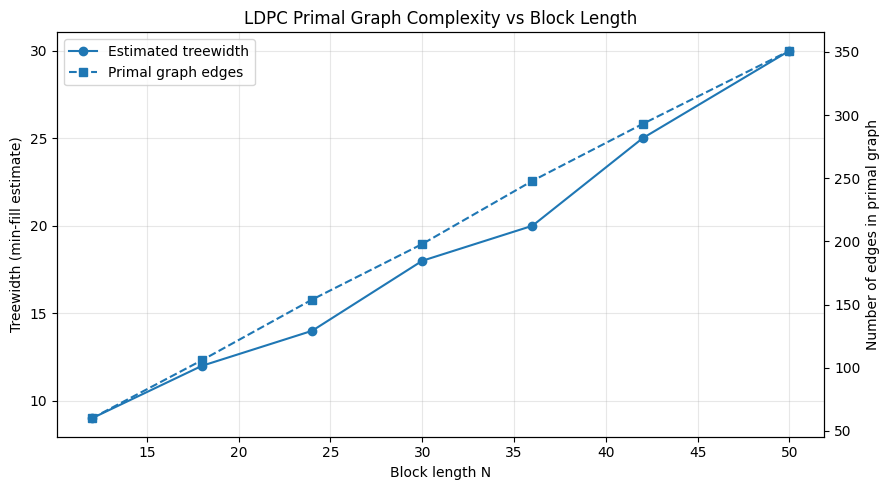

In [122]:
from networkx.algorithms.approximation import treewidth_min_fill_in
import matplotlib.pyplot as plt

def ldpc_primal_graph_on_x(G):
    """Build the primal graph on x-variables only.

    Nodes: x0..x{N-1}
    Edge between xi and xj if some parity-check factor contains both.

    This constructs the variable-interaction graph induced by
    eliminating factor nodes. Two variables are adjacent if they
    co-occur in at least one parity constraint.
    """
    primal = nx.Graph()

    # Separate factor objects from variable nodes in the factor graph
    factors = list(G.get_factors())
    factor_set = set(factors)
    variable_nodes = [node for node in G.nodes() if node not in factor_set]

    # Extract x-variables only (exclude y variables),
    # and sort them numerically by index.
    x_vars = sorted(
        [v for v in variable_nodes if isinstance(v, str) and v.startswith("x")],
        key=lambda s: int(s[1:])
    )

    # Add all x variables as nodes in the primal graph
    primal.add_nodes_from(x_vars)

    # Identify parity factors only (ignore channel factors)
    # since channel factors do not create x-x interactions.
    parity_factors = [
        fac for fac in factors
        if all(v.startswith("x") for v in fac.variables)
    ]

    # For each parity factor of degree d, create a clique
    # among its variables. This corresponds to the standard
    # construction of a primal graph from a factor graph:
    # variables sharing a factor become fully connected.
    for fac in parity_factors:
        scope = list(fac.variables)

        # Add edges between every unordered pair in the factor scope
        # If a parity check involves {x1, x3, x7},
        # we add edges (x1,x3), (x1,x7), (x3,x7).
        for i in range(len(scope)):
            for j in range(i + 1, len(scope)):
                primal.add_edge(scope[i], scope[j])

    return primal


def treewidth_scaling_experiment(N_list, j, k, f=0.08, seed0=0):
    """Estimate treewidth scaling for increasing block lengths N.

    For each N:
      - Generate a (j,k)-regular LDPC parity-check matrix H.
      - Build the corresponding factor graph.
      - Construct the primal graph on x variables.
      - Estimate its treewidth using the min-fill heuristic.

    Returns:
        List of tuples (N, estimated_treewidth, num_edges),
        where num_edges is the number of edges in the primal graph.
    """
    results = []

    for idx, N in enumerate(N_list):

        # For a (j,k)-regular LDPC code:
        #   N * j = M * k  must hold.
        # So N*j must be divisible by k.
        if (N * j) % k != 0:
            print(f"Skipping N={N}: N*j must be divisible by k.")
            continue

        # Generate regular LDPC parity-check matrix
        H = generate_regular_ldpc_H(N=N, j=j, k=k, seed=seed0 + idx)

        # Build LDPC factor graph (parity + channel factors)
        G = build_ldpc_factor_graph(H, f=f)

        # Construct primal variable-interaction graph
        primal = ldpc_primal_graph_on_x(G)

        # Estimate treewidth using the min-fill heuristic.
        # This is an upper-bound estimate, not exact treewidth.
        # It reflects approximate elimination complexity.
        tw_estimate, _ = treewidth_min_fill_in(primal)

        # Store:
        #   N              → block length
        #   tw_estimate    → estimated treewidth
        #   number_of_edges→ density of variable interactions
        results.append((N, int(tw_estimate), primal.number_of_edges()))

    return results


# Block lengths to test
N_list = [12, 18, 24, 30, 36, 42, 50]

# (j,k)-regular LDPC parameters:
#   j = variable degree
#   k = check degree
j, k = 3, 6

# Run scaling experiment
tw_results = treewidth_scaling_experiment(N_list, j=j, k=k, f=0.08, seed0=0)
tw_results


if len(tw_results) > 0:
    # Extract data columns
    Ns = [r[0] for r in tw_results]
    tws = [r[1] for r in tw_results]
    edges = [r[2] for r in tw_results]

    # Create figure for joint visualization
    fig, ax1 = plt.subplots(figsize=(9, 5))

    # Plot estimated treewidth vs block length
    line1 = ax1.plot(Ns, tws, marker="o", label="Estimated treewidth")
    ax1.set_xlabel("Block length N")
    ax1.set_ylabel("Treewidth (min-fill estimate)")
    ax1.grid(True, alpha=0.3)

    # Secondary axis: number of edges in primal graph
    # This reflects how dense the variable interaction graph becomes.
    ax2 = ax1.twinx()
    line2 = ax2.plot(Ns, edges, marker="s", linestyle="--",
                     label="Primal graph edges")
    ax2.set_ylabel("Number of edges in primal graph")

    # Combine legends from both axes
    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper left")

    plt.title("LDPC Primal Graph Complexity vs Block Length")
    plt.tight_layout()
    plt.show()